In [2]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

NUM_CLASSES = 20
IMAGE_EMBEDDING_DIM = 2048
TEXT_EMBEDDING_DIM = 768

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.14.0
Device: mps


1. Build the Image Encoder

In [3]:
weights = models.ResNet50_Weights.DEFAULT

resnet = models.resnet50(
    weights=weights
)

resnet.fc = nn.Linear(
    IMAGE_EMBEDDING_DIM,
    NUM_CLASSES
)

resnet.load_state_dict(
    torch.load(
        "../models/resnet50_best.pth",
        map_location=device
    )
)

resnet = resnet.to(device)

In [4]:
image_encoder = nn.Sequential(
    *list(resnet.children())[:-1]
)

image_encoder = image_encoder.to(device)
image_encoder.eval()

print("Image encoder loaded.")

Image encoder loaded.


2. Verify Image Embedding

In [5]:
%run ./02_Data_Preparation.ipynb

Device: mps
Train: (29901, 6)
Validation: (6435, 6)
Test: (6459, 6)
../data/raw/fashion-product-images-small/images/15970.jpg
Exists: True
Image size: (60, 80)
Image mode: RGB
Image mode: RGB
Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tenosr min: -2.0836544036865234
Tensor max: 2.640000104904175
Dataset size: 29901
Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: tensor(17)
Label dtype: torch.int64
index 0: shape=torch.Size([3, 224, 224]), label=17
index 100: shape=torch.Size([3, 224, 224]), label=17
index 1000: shape=torch.Size([3, 224, 224]), label=13
index 5000: shape=torch.Size([3, 224, 224]), label=17
index 10000: shape=torch.Size([3, 224, 224]), label=0
Train datasets: 29901
Validation datasets: 6435
Test dataset: 6459
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Images dtype: torch.float32
Label dtype: torch.int64
Labels: tensor([17,  0, 17, 16,  6,  1,  7, 17, 17, 17, 19,  0, 13, 15, 19, 17, 17,  8,


Text: Turtle Check Men Navy Blue Shirt
Input IDs shape: torch.Size([1, 32])
Attention mask shape: torch.Size([1, 32])
['[CLS]', 'turtle', 'check', 'men', 'navy', 'blue', 'shirt', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])
Orignal : Turtle Check Men Navy Blue Shirt
Decoded : turtle check men navy blue shirt
Input IDs shape: torch.Size([8, 32])
Attention mask shape: torch.Size([8, 32])
Maximum token length:  30
Texts with > 32 tokens: 0
Multimodal train dataset: 29901
dict_keys(['image', 'input_ids', 'attention_mask', 'label'])
Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Input IDs shape: torch.Size([32])
Input IDs dtype: torch.int64
Attention mask shape: torch.Size([32])
At

In [6]:
images, labels = next(
    iter(test_loader)
)

images = images.to(device)

with torch.no_grad():
    image_features = image_encoder(images)

image_features = torch.flatten(
    image_features,
    start_dim=1
)

print("Image features:", image_features.shape)

Image features: torch.Size([32, 2048])


3. Load the Trained Text Encoder

In [7]:
from transformers import AutoModel

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 32


class DistilBERTTextEncoder(nn.Module):

    def __init__(
        self,
        model_name="distilbert-base-uncased"
    ):
        super().__init__()

        self.transformer = AutoModel.from_pretrained(
            model_name
        )

        self.hidden_size = (
            self.transformer.config.hidden_size
        )

    def masked_mean_pooling(
        self,
        last_hidden_state,
        attention_mask
    ):
        mask = attention_mask.unsqueeze(-1).expand(
            last_hidden_state.size()
        ).float()

        summed_embeddings = torch.sum(
            last_hidden_state * mask,
            dim=1
        )

        token_count = torch.clamp(
            mask.sum(dim=1),
            min=1e-9
        )

        return summed_embeddings / token_count

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_embedding = self.masked_mean_pooling(
            outputs.last_hidden_state,
            attention_mask
        )

        return text_embedding

In [8]:
class TextClassifier(nn.Module):

    def __init__(
        self,
        model_name="distilbert-base-uncased",
        num_classes=20
    ):
        super().__init__()

        self.text_encoder = DistilBERTTextEncoder(
            model_name
        )

        self.classifier = nn.Linear(
            self.text_encoder.hidden_size,
            num_classes
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        text_embedding = self.text_encoder(
            input_ids,
            attention_mask
        )

        logits = self.classifier(
            text_embedding
        )

        return logits

In [9]:
text_classifier = TextClassifier(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES
)

text_classifier.load_state_dict(
    torch.load(
        "../models/distilbert_text_classifier_best.pth",
        map_location=device
    )
)

text_classifier = text_classifier.to(device)
text_classifier.eval()

print("Text model loaded.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text model loaded.


4. Extract the Text Encoder

In [10]:
text_encoder = text_classifier.text_encoder

text_encoder = text_encoder.to(device)
text_encoder.eval()

print(
    "Text embedding dimension:",
    text_encoder.hidden_size
)

Text embedding dimension: 768


In [11]:
batch = next(
    iter(multimodal_test_loader)
)

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

with torch.no_grad():

    text_features = text_encoder(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

print("Text features:", text_features.shape)

Text features: torch.Size([32, 768])


5. Create the Multimodal Fusion Model

In [12]:
class MultimodalClassifier(nn.Module):

    def __init__(
        self,
        image_encoder,
        text_encoder,
        num_classes=20
    ):
        super().__init__()

        self.image_encoder = image_encoder
        self.text_encoder = text_encoder

        # Image projection
        self.image_projection = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU()
        )

        # Text projection
        self.text_projection = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU()
        )

        # Fusion classifier
        self.fusion = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(
        self,
        images,
        input_ids,
        attention_mask
    ):

        # Image features
        image_features = self.image_encoder(
            images
        )

        image_features = torch.flatten(
            image_features,
            start_dim=1
        )

        # Text features
        text_features = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Project both modalities
        image_features = self.image_projection(
            image_features
        )

        text_features = self.text_projection(
            text_features
        )

        # Concatenate
        fused_features = torch.cat(
            [image_features, text_features],
            dim=1
        )

        # Final classification
        logits = self.fusion(
            fused_features
        )

        return logits

6. Freeze Both Pretrained Encoder

In [13]:
for param in image_encoder.parameters():
    param.requires_grad = False

for param in text_encoder.parameters():
    param.requires_grad = False

7. Create the Multimodal Model

In [14]:
multimodal_model = MultimodalClassifier(
    image_encoder=image_encoder,
    text_encoder=text_encoder,
    num_classes=NUM_CLASSES
)

multimodal_model = multimodal_model.to(device)

print(multimodal_model)

MultimodalClassifier(
  (image_encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=Tru

In [15]:
total_params = sum(
    p.numel()
    for p in multimodal_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in multimodal_model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 91581268
Trainable parameters: 1710356


In [16]:
print("\nTrainable layers:")

for name, param in multimodal_model.named_parameters():

    if param.requires_grad:
        print(
            name,
            param.shape
        )


Trainable layers:
image_projection.0.weight torch.Size([512, 2048])
image_projection.0.bias torch.Size([512])
text_projection.0.weight torch.Size([512, 768])
text_projection.0.bias torch.Size([512])
fusion.0.weight torch.Size([256, 1024])
fusion.0.bias torch.Size([256])
fusion.3.weight torch.Size([20, 256])
fusion.3.bias torch.Size([20])


8. Test the Complete Multimodal Forward Pass

In [17]:
batch = next(
    iter(multimodal_test_loader)
)

images = batch["image"].to(device)
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["label"].to(device)

with torch.no_grad():

    logits = multimodal_model(
        images=images,
        input_ids=input_ids,
        attention_mask=attention_mask
    )

print("Image shape:", images.shape)
print("Input IDs shape:", input_ids.shape)
print("Attention mask shape:", attention_mask.shape)
print("Labels shape:", labels.shape)
print("Logits shape:", logits.shape)

Image shape: torch.Size([32, 3, 224, 224])
Input IDs shape: torch.Size([32, 32])
Attention mask shape: torch.Size([32, 32])
Labels shape: torch.Size([32])
Logits shape: torch.Size([32, 20])


### Multimodal Architecture Design & Encoder Integration

- Integrated trained ResNet-50 image encoder
- Integrated trained DistilBERT text encoder
- Image representation: 2048 dimensions
- Text representation: 768 dimensions
- Image projection: 2048 → 512
- Text projection: 768 → 512
- Fused representation: 1024 dimensions
- Fusion layer: 1024 → 256
- Dropout: 0.3
- Classification layer: 256 → 20
- ResNet-50 backbone frozen
- DistilBERT backbone frozen
- Projection and fusion layers trainable
- Total parameters: 91,581,268
- Trainable parameters: 1,710,356
- Verified complete multimodal forward pass
- Final logits shape: [32, 20]

9. Cross-Entropy Loss

In [18]:
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [19]:
optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        multimodal_model.parameters()
    ),
    lr=1e-3
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [20]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

print("Scheduler:", scheduler)

Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x1472a4c20>


In [21]:
optimizer_params = sum(
    p.numel()
    for group in optimizer.param_groups
    for p in group["params"]
)

print(
    "Parameters passed to optimizer:",
    optimizer_params
)

Parameters passed to optimizer: 1710356


10. Verify Frozen Parameters

In [22]:
trainable_backbone_params = []

for name, param in multimodal_model.named_parameters():

    if param.requires_grad and (
        name.startswith("image_encoder")
        or name.startswith("text_encoder")
    ):
        trainable_backbone_params.append(name)

print(
    "Trainable backbone parameters:",
    trainable_backbone_params
)

Trainable backbone parameters: []


11. Count Parameters by Component

In [23]:
component_params = {
    "image_encoder": sum(
        p.numel()
        for p in multimodal_model.image_encoder.parameters()
    ),
    "text_encoder": sum(
        p.numel()
        for p in multimodal_model.text_encoder.parameters()
    ),
    "image_projection": sum(
        p.numel()
        for p in multimodal_model.image_projection.parameters()
    ),
    "text_projection": sum(
        p.numel()
        for p in multimodal_model.text_projection.parameters()
    ),
    "fusion": sum(
        p.numel()
        for p in multimodal_model.fusion.parameters()
    )
}

for name, count in component_params.items():
    print(f"{name}: {count:,}")

image_encoder: 23,508,032
text_encoder: 66,362,880
image_projection: 1,049,088
text_projection: 393,728
fusion: 267,540


### Configure Multimodal Training

- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Learning rate: 0.001
- Scheduler: ReduceLROnPlateau
- ResNet-50 encoder: Frozen
- DistilBERT encoder: Frozen
- Image projection: Trainable
- Text projection: Trainable
- Fusion network: Trainable
- Parameters passed to optimizer: 1,710,356
- Verified no encoder parameters are trainable
- Verified component parameter counts

12. Training Function

In [24]:
def train_multimodal_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    model.train()

    # Keep the pretrained encoders frozen
    model.image_encoder.eval()
    model.text_encoder.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in dataloader:

        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(
            images=images,
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Calculate loss
        loss = criterion(
            logits,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update trainable projection/fusion layers
        optimizer.step()

        # Statistics
        running_loss += (
            loss.item() * labels.size(0)
        )

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

13. Validation Function

In [25]:
def validate_multimodal_one_epoch(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for batch in dataloader:

            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(
                images=images,
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(
                logits,
                labels
            )

            running_loss += (
                loss.item() * labels.size(0)
            )

            predictions = logits.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [26]:
NUM_EPOCHS = 5

multimodal_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

14. Train the Fusion Model

In [27]:
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):

    train_loss, train_accuracy = train_multimodal_one_epoch(
        multimodal_model,
        multimodal_train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate_multimodal_one_epoch(
        multimodal_model,
        multimodal_val_loader,
        criterion,
        device
    )

    # Update scheduler
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # Save history
    multimodal_history["train_loss"].append(
        train_loss
    )

    multimodal_history["train_accuracy"].append(
        train_accuracy
    )

    multimodal_history["val_loss"].append(
        val_loss
    )

    multimodal_history["val_accuracy"].append(
        val_accuracy
    )

    multimodal_history["learning_rate"].append(
        current_lr
    )

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            multimodal_model.state_dict(),
            "../models/multimodal_best.pth"
        )

        print("  ✓ Best multimodal model saved")

Epoch [1/5] | Train Loss: 0.2860 | Train Acc: 0.9183 | Val Loss: 0.0737 | Val Acc: 0.9781 | LR: 0.001000
  ✓ Best multimodal model saved
Epoch [2/5] | Train Loss: 0.0671 | Train Acc: 0.9798 | Val Loss: 0.0446 | Val Acc: 0.9877 | LR: 0.001000
  ✓ Best multimodal model saved
Epoch [3/5] | Train Loss: 0.0465 | Train Acc: 0.9864 | Val Loss: 0.0599 | Val Acc: 0.9841 | LR: 0.001000
Epoch [4/5] | Train Loss: 0.0367 | Train Acc: 0.9888 | Val Loss: 0.0474 | Val Acc: 0.9879 | LR: 0.001000
Epoch [5/5] | Train Loss: 0.0327 | Train Acc: 0.9903 | Val Loss: 0.0431 | Val Acc: 0.9893 | LR: 0.001000
  ✓ Best multimodal model saved


15. Load the Best Multimodal Checkpoint

In [28]:
# Load the best multimodal model
best_model_path = "../models/multimodal_best.pth"

multimodal_model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

multimodal_model = multimodal_model.to(device)
multimodal_model.eval()

print("Best multimodal model loaded")

Best multimodal model loaded


16. Create the Evaluation Function

In [29]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np


def evaluate_multimodal_model(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in dataloader:

            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(
                images=images,
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(logits, labels)

            predictions = logits.argmax(dim=1)

            running_loss += loss.item() * labels.size(0)
            total += labels.size(0)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    test_loss = running_loss / total

    test_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted"
    )

    return (
        test_loss,
        test_accuracy,
        macro_f1,
        weighted_f1,
        np.array(all_labels),
        np.array(all_predictions)
    )

17. Run Test Evaluation

In [30]:
(
    test_loss,
    test_accuracy,
    macro_f1,
    weighted_f1,
    y_true,
    y_pred
) = evaluate_multimodal_model(
    multimodal_model,
    multimodal_test_loader,
    criterion,
    device
)

print(f"Test Loss:       {test_loss:.4f}")
print(f"Test Accuracy:   {test_accuracy:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Weighted F1:     {weighted_f1:.4f}")

Test Loss:       0.0320
Test Accuracy:   0.9921
Macro F1:        0.9776
Weighted F1:     0.9921


18. Classification Report

In [33]:
class_names = [
    name for name, label in sorted(
        label_mapping.items(),
        key=lambda x: x[1]
    )
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                          precision    recall  f1-score   support

                    Bags     0.9783    1.0000    0.9890       450
                   Belts     1.0000    1.0000    1.0000       128
              Bottomwear     0.9920    0.9816    0.9868       380
                   Dress     0.9800    0.9423    0.9608        52
                 Eyewear     1.0000    1.0000    1.0000       134
              Flip Flops     0.9645    0.9855    0.9749       138
               Fragrance     0.9937    1.0000    0.9968       157
               Innerwear     0.9962    0.9887    0.9924       265
               Jewellery     1.0000    0.9947    0.9973       188
                    Lips     0.9451    1.0000    0.9718        86
Loungewear and Nightwear     0.8814    0.9630    0.9204        54
                  Makeup     1.0000    0.8000    0.8889        35
                   Nails     0.9487    1.0000    0.9737        37
                  Sandal     0.9124    0.9690    0.9398       129
         

19. Confusion Matrix

In [34]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix Shape:", cm.shape)
print(cm)

Confusion Matrix Shape: (20, 20)
[[ 450    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0  128    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0  373    1    0    0    0    0    0    0    5    0    0    1
     0    0    0    0    0    0]
 [   0    0    0   49    0    0    0    0    0    0    0    0    0    0
     0    0    0    3    0    0]
 [   0    0    0    0  134    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0    0  136    0    0    0    0    0    0    0    2
     0    0    0    0    0    0]
 [   0    0    0    0    0    0  157    0    0    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    1    0    0    0    0  262    0    0    2    0    0    0
     0    0    0    0    0    0]
 [   1    0    0    0    0    0    0    0  187    0    0    0    0    0
     0    0    0    0    0    0]
 [   0    0    0    0 

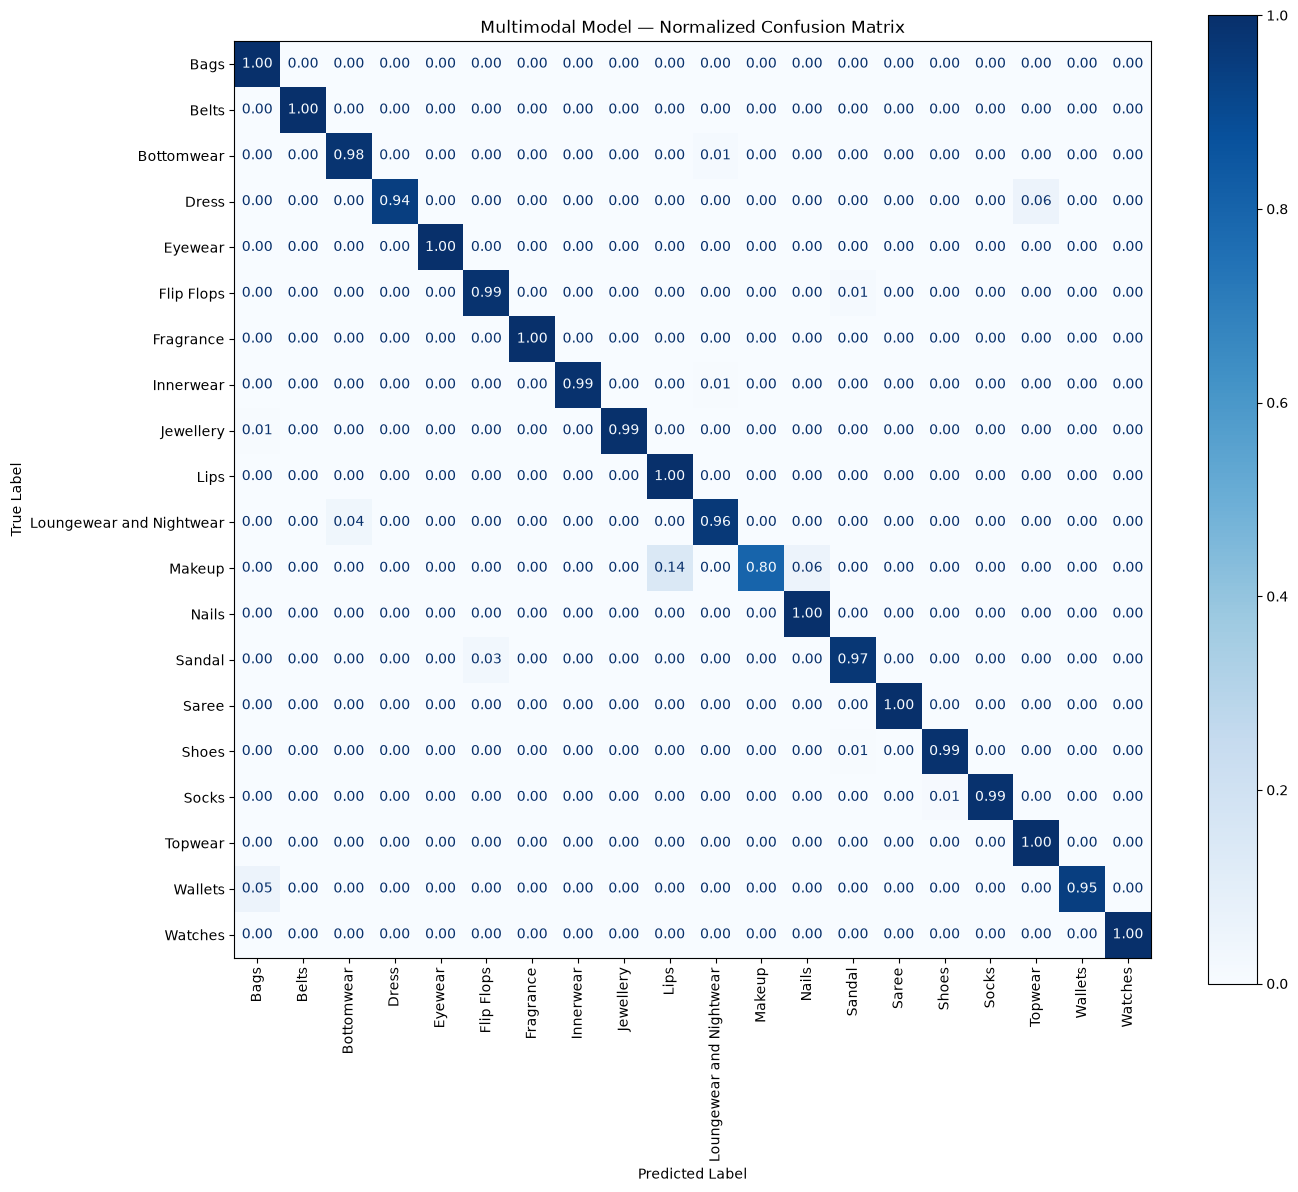

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# Normalize each row by the number of true samples
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    values_format=".2f"
)

ax.set_title("Multimodal Model — Normalized Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

### Multimodal Fusion Results

The multimodal classifier combines pretrained ResNet-50 image embeddings
(2048 dimensions) and DistilBERT text embeddings (768 dimensions) through
learnable projection and fusion layers.

#### Test Performance

- Test Loss: 0.0320
- Test Accuracy: 99.21%
- Macro F1: 97.76%
- Weighted F1: 99.21%

#### Comparison

| Model | Accuracy | Macro F1 | Weighted F1 |
|-------|----------|----------|-------------|
| Image-only (ResNet-50) | 94.04% | 86.40% | 93.84% |
| Text-only (DistilBERT) | 97.77% | 96.51% | 97.76% |
| Multimodal | 99.21% | 97.76% | 99.21% |

The multimodal model outperformed both individual modalities on the
held-out test set, demonstrating the benefit of combining visual and
textual product information.